In [1]:
import sympy.printing          # this build does not attach the submodule; torch expects it

import numpy as np
import torch
import torch.nn as nn
from einops import rearrange, reduce
from torchvision.models import resnet18, ResNet18_Weights


import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import visualization.visualization as vis
from nemi import NEMI, SingleNemi

import torch
import numpy as np

import colorsys
from einops import rearrange
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

import itertools

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
s = SingleNemi(params={'device':'gpu','embedding_dict':{'n_components':3,'n_neighbors':15}}); s.fit_embedding(np.random.rand(500, 8).astype('float32')); print('ok')

ok


In [3]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="2_02",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [ ]:
raw = cutouts_dataset.RawCutouts.download(source, subset=False,
                                          subsample_per_chunk=64, num_sample_chunks=1, n_workers=4)

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45893 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:40585' processes=4 threads=16, memory=128.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/45893/status


In [4]:
patch_size = 8

In [5]:
data_channels = ["Theta", "Salt", "Eta", "gradb2", "relative_vorticity","strain_mag", "strain_n", "strain_s", "divergence", "coriolis_f"]

dataset = raw.select(data_channels)

features ['Theta', 'Salt', 'Eta', 'gradb2', 'relative_vorticity', 'strain_mag', 'strain_n', 'strain_s', 'divergence', 'coriolis_f'] | coords ['XC', 'YC']


In [6]:
EMBEDDING_DIMENSIONS = 3
ENSEMBLE_MEMEBERS = 5

In [7]:
OMEGA        = 7.2921e-5
DIV_SIGNED   = ("relative_vorticity",)                          # signed f: cyclonic positive in both hemispheres
DIV_ABS      = ("strain_n", "strain_s", "divergence")           # |f|: strain stays positive, convergence stays convergence
N_NEIGHBORS  = (50, 100)
ALWAYS_LOAD  = ("gradb2", "coriolis_f")                         # colour source and f divisor, loaded whether or not listed


def _prepared(X, name, ix, cfg, lg, f_signed):
    """One channel of (N, H, W), after log / division by f."""
    if name == "gradb2":
        return lg
    a = X[:, ix[name]]
    if cfg.get("div_by_f") and name in DIV_SIGNED:
        return a / f_signed
    if cfg.get("div_by_f") and name in DIV_ABS:
        return a / np.abs(f_signed)
    return a


def build_patch_data(raw, cfg, equator_deg=5.0, block=256):
    """The patch matrix for one config, ready for a NEMI run.

    cfg is {"channels": [...], "patch_size": int, "div_by_f": bool, "name": str}.
    coriolis_f never enters the features; gradb2 and coriolis_f are always loaded so the
    colour and the divisor are available regardless of what is listed.  Channels are
    z-scored globally, one mean/std each, after the log and the f-division.

    Returns {"name", "params", "feature_channels", "X", "colour", "near_equator"},
    all rows in get_patches order.
    """
    for k in ("channels", "patch_size", "name"):
        if k not in cfg:
            raise ValueError(f"config missing '{k}': {cfg}")
    feat = [c for c in cfg["channels"] if c != "coriolis_f"]
    load = list(dict.fromkeys(feat + list(ALWAYS_LOAD)))
    ps = cfg["patch_size"]
    f_floor = 2 * OMEGA * np.sin(np.deg2rad(equator_deg))

    ds = raw.select(load)
    X = ds.X
    if X.shape[2] % ps or X.shape[3] % ps:
        raise ValueError(f"patch_size {ps} does not divide {X.shape[2:]}")
    ix = {c: ds.channel_names.index(c) for c in load}

    g = X[:, ix["gradb2"]]
    s = g[::max(1, len(g) // 64)]
    gfloor = float(s[s > 0].min()) if (s > 0).any() else 1e-20

    # pass 1: one mean/std per channel, over every pixel of every cutout
    cnt = 0
    s1 = np.zeros(len(feat)); s2 = np.zeros(len(feat))
    for i in range(0, len(X), block):
        cut = np.asarray(X[i:i + block], dtype="float32")
        f = cut[:, ix["coriolis_f"]]
        fs = np.where(f < 0, -1.0, 1.0) * np.maximum(np.abs(f), f_floor)
        lg = np.log10(np.where(cut[:, ix["gradb2"]] > 0, cut[:, ix["gradb2"]], gfloor))
        for c, name in enumerate(feat):
            a = _prepared(cut, name, ix, cfg, lg, fs).astype(np.float64)
            s1[c] += a.sum(); s2[c] += (a ** 2).sum()
        cnt += cut[:, 0].size
    mu = s1 / cnt
    sd = np.sqrt(np.maximum(s2 / cnt - mu ** 2, 0.0))

    # pass 2: z-score, patchify, and collect the colour + equator flag
    parts, colour, near_eq = [], [], []
    for i in range(0, len(X), block):
        cut = np.asarray(X[i:i + block], dtype="float32")
        f = cut[:, ix["coriolis_f"]]
        fs = np.where(f < 0, -1.0, 1.0) * np.maximum(np.abs(f), f_floor)
        lg = np.log10(np.where(cut[:, ix["gradb2"]] > 0, cut[:, ix["gradb2"]], gfloor))
        cols = []
        for c, name in enumerate(feat):
            a = (_prepared(cut, name, ix, cfg, lg, fs) - mu[c]) / (sd[c] + 1e-30)
            cols.append(rearrange(a, 'n (h p1) (w p2) -> (n h w) (p1 p2)', p1=ps, p2=ps))
        parts.append(np.hstack(cols).astype("float32"))
        colour.append(reduce(lg, 'n (h p1) (w p2) -> (n h w)', 'mean', p1=ps, p2=ps))
        near_eq.append(reduce((np.abs(f) < f_floor).astype("float32"),
                              'n (h p1) (w p2) -> (n h w)', 'max', p1=ps, p2=ps) > 0)

    out = {"name": cfg["name"], "params": dict(cfg), "feature_channels": feat,
           "X": np.ascontiguousarray(np.vstack(parts), dtype="float32"),
           "colour": np.concatenate(colour),
           "near_equator": np.concatenate(near_eq)}
    parts = None
    gc.collect()
    return out


def build_embeddings(raw, configs, n_components=3, min_dist=0.0, equator_deg=5.0,
                     fit_n=None, block=256, device="gpu", seed=0):
    """Two UMAP embeddings (n_neighbors 50 and 100) per config, over build_patch_data."""
    rng = np.random.default_rng(seed)
    results = []

    for cfg in configs:
        d = build_patch_data(raw, cfg, equator_deg=equator_deg, block=block)
        F, colour, near_eq = d["X"], d["colour"], d["near_equator"]

        idx = (np.sort(rng.choice(len(F), fit_n, replace=False))
               if fit_n and fit_n < len(F) else np.arange(len(F)))
        Xf = np.ascontiguousarray(F[idx], dtype="float32")
        F = d["X"] = None
        gc.collect()

        embs = {}
        for nn in N_NEIGHBORS:
            m = SingleNemi(params={"device": device,
                                   "embedding_dict": {"n_components": n_components,
                                                      "n_neighbors": nn,
                                                      "min_dist": min_dist}})
            m.fit_embedding(Xf)
            embs[nn] = np.asarray(m.embedding)
            m = None
            gc.collect()

        results.append({"name": d["name"], "params": d["params"],
                        "feature_channels": d["feature_channels"],
                        "dims": Xf.shape[1], "n_patches": len(colour), "fit_index": idx,
                        "colour": colour[idx], "near_equator": near_eq[idx],
                        "embeddings": embs})
        ps = cfg["patch_size"]
        print(f"{d['name']}\n    {len(d['feature_channels'])} channels x {ps*ps} px = "
              f"{Xf.shape[1]} dims | {len(colour):,} patches | fit on {len(Xf):,} | "
              f"{int(near_eq[idx].sum()):,} near-equator")
        Xf = None
        gc.collect()

    return results


def plot_embeddings(results, disp_n=60_000, point_size=0.5, alpha=0.25,
                    title_size=17, seed=0):
    """Two rows (n_neighbors 50 / 100) x one column per config, on a shared colour scale."""
    rng = np.random.default_rng(seed)
    rows, cols = len(N_NEIGHBORS), len(results)
    allc = np.concatenate([r["colour"] for r in results])
    lo, hi = np.nanpercentile(allc, [2, 98])

    fig = plt.figure(figsize=(6.0 * cols, 5.6 * rows))
    for c, r in enumerate(results):
        sub = rng.choice(len(r["colour"]), size=min(disp_n, len(r["colour"])), replace=False)
        v = r["colour"][sub]
        for k, nn in enumerate(N_NEIGHBORS):
            E = r["embeddings"][nn][sub]
            ax = fig.add_subplot(rows, cols, k * cols + c + 1, projection="3d")
            sc = ax.scatter(E[:, 0], E[:, 1], E[:, 2], c=v, cmap="viridis", vmin=lo, vmax=hi,
                            s=point_size, alpha=alpha, linewidths=0)
            ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
            if c == 0:
                ax.text2D(-0.08, 0.5, f"n_neighbors = {nn}", transform=ax.transAxes,
                          rotation=90, va="center", ha="center", fontsize=title_size - 2)
            if k == 0:
                ax.set_title(f"{r['name']}\n{r['dims']} dims, {r['n_patches']:,} patches",
                             fontsize=title_size, pad=14)
            if c == cols - 1 and k == 0:
                fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label="mean log10 gradb2")
    fig.tight_layout()
    plt.show()
    return fig

In [8]:
# layer -> spatial stride on the cutout, so the feature map lands on the patch grid
RESNET_STRIDE = {"layer1": 4, "layer2": 8, "layer3": 16, "layer4": 32}
RESNET_DIM    = {"layer1": 64, "layer2": 128, "layer3": 256, "layer4": 512}


def _resnet_trunk(patch_size, device):
    """ResNet-18 truncated at the layer whose output stride equals patch_size.

    A 64x64 cutout gives 16x16 at layer1 and 8x8 at layer2, so one feature vector
    lands on each patch by construction -- no interpolation, and each patch is seen
    with the surrounding context its receptive field covers.
    """
    layer = next((k for k, s in RESNET_STRIDE.items() if s == patch_size), None)
    if layer is None:
        raise ValueError(f"patch_size {patch_size} has no matching ResNet stride; "
                         f"supported: {sorted(RESNET_STRIDE.values())}")
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    keep = ["layer1", "layer2", "layer3", "layer4"]
    mods = [m.conv1, m.bn1, m.relu, m.maxpool]
    for k in keep[:keep.index(layer) + 1]:
        mods.append(getattr(m, k))
    return nn.Sequential(*mods).eval().to(device), RESNET_DIM[layer], layer


@torch.no_grad()
def cnn_patch_embeddings(raw, cfg, equator_deg=5.0, block=64, device="cuda"):
    """Pretrained ResNet-18 features for every patch, in get_patches order.

    Preprocessing matches build_patch_data: gradb2 logged, kinematics divided by f
    when div_by_f, then one global mean/std per channel.  Each physical channel is
    replicated to RGB and passed through separately, so a feature stays attributable
    to the field it came from; the per-channel outputs are concatenated.

    Returns {"name", "params", "feature_channels", "layer", "X", "colour",
             "near_equator"} with X of shape (n_patches, C * layer_dim).
    """
    for k in ("channels", "patch_size", "name"):
        if k not in cfg:
            raise ValueError(f"config missing '{k}': {cfg}")
    feat = [c for c in cfg["channels"] if c != "coriolis_f"]
    load = list(dict.fromkeys(feat + list(ALWAYS_LOAD)))
    ps = cfg["patch_size"]
    f_floor = 2 * OMEGA * np.sin(np.deg2rad(equator_deg))

    ds = raw.select(load)
    X = ds.X
    if X.shape[2] % ps or X.shape[3] % ps:
        raise ValueError(f"patch_size {ps} does not divide {X.shape[2:]}")
    ix = {c: ds.channel_names.index(c) for c in load}

    g = X[:, ix["gradb2"]]
    s = g[::max(1, len(g) // 64)]
    gfloor = float(s[s > 0].min()) if (s > 0).any() else 1e-20

    # pass 1: one mean/std per channel, over every pixel of every cutout
    cnt = 0
    s1 = np.zeros(len(feat)); s2 = np.zeros(len(feat))
    for i in range(0, len(X), block):
        cut = np.asarray(X[i:i + block], dtype="float32")
        f = cut[:, ix["coriolis_f"]]
        fs = np.where(f < 0, -1.0, 1.0) * np.maximum(np.abs(f), f_floor)
        lg = np.log10(np.where(cut[:, ix["gradb2"]] > 0, cut[:, ix["gradb2"]], gfloor))
        for c, name in enumerate(feat):
            a = _prepared(cut, name, ix, cfg, lg, fs).astype(np.float64)
            s1[c] += a.sum(); s2[c] += (a ** 2).sum()
        cnt += cut[:, 0].size
    mu = s1 / cnt
    sd = np.sqrt(np.maximum(s2 / cnt - mu ** 2, 0.0))

    trunk, dim, layer = _resnet_trunk(ps, device)

    # pass 2: z-score, one forward pass per channel, read the feature map on the patch grid
    parts, colour, near_eq = [], [], []
    for i in range(0, len(X), block):
        cut = np.asarray(X[i:i + block], dtype="float32")
        f = cut[:, ix["coriolis_f"]]
        fs = np.where(f < 0, -1.0, 1.0) * np.maximum(np.abs(f), f_floor)
        lg = np.log10(np.where(cut[:, ix["gradb2"]] > 0, cut[:, ix["gradb2"]], gfloor))
        chans = []
        for c, name in enumerate(feat):
            a = (_prepared(cut, name, ix, cfg, lg, fs) - mu[c]) / (sd[c] + 1e-30)
            t = torch.from_numpy(np.ascontiguousarray(a, dtype="float32")).to(device)
            t = t.unsqueeze(1).repeat(1, 3, 1, 1)                 # grayscale -> RGB
            out = trunk(t)                                        # (n, dim, H/ps, W/ps)
            chans.append(rearrange(out, 'n d h w -> (n h w) d').cpu().numpy())
        parts.append(np.hstack(chans).astype("float32"))
        colour.append(reduce(lg, 'n (h p1) (w p2) -> (n h w)', 'mean', p1=ps, p2=ps))
        near_eq.append(reduce((np.abs(f) < f_floor).astype("float32"),
                              'n (h p1) (w p2) -> (n h w)', 'max', p1=ps, p2=ps) > 0)
        del chans
        if device == "cuda":
            torch.cuda.empty_cache()

    out = {"name": cfg["name"], "params": dict(cfg), "feature_channels": feat,
           "layer": layer,
           "X": np.ascontiguousarray(np.vstack(parts), dtype="float32"),
           "colour": np.concatenate(colour),
           "near_equator": np.concatenate(near_eq)}
    parts = None
    trunk = None
    gc.collect()
    print(f"{cfg['name']}\n    ResNet-18 {layer} ({dim}-d) x {len(feat)} channels = "
          f"{out['X'].shape[1]} dims | {len(out['X']):,} patches")
    return out

In [12]:
#DATA chosen 
#"Theta", "Salt", "gradb2", "relative_vorticity","strain_n", "strain_s", "divergence"
import gc
run_params = {"channels" : ["Theta", "Salt", "gradb2"],
                     "patch_size" : 8,
                     "div_by_f" : True,
                     "name" : "PatchSize=2 Nondimensionalized Kinematics"
                    }



#d = build_patch_data(raw, data_channels_all_8) 
# d["X"]            # (n_patches, dims) float32, contiguous, ready for SingleNemi
# d["colour"]       # per-patch mean log10 gradb2
# d["near_equator"] # per-patch bool




d = cnn_patch_embeddings(raw, run_params)
X = d["X"]          # (n_patches, C * layer_dim), get_patches order
# d["colour"]         # mean log10 gradb2 per patch
# d["near_equator"]

features ['Theta', 'Salt', 'gradb2', 'coriolis_f'] | coords ['XC', 'YC']
PatchSize=2 Nondimensionalized Kinematics
    ResNet-18 layer2 (128-d) x 3 channels = 384 dims | 1,890,176 patches


In [13]:
## Run NEMI on the patches (GPU: cuML UMAP + clustering)
# nemi = NEMI(params={
#     "device": "gpu",
#     "embedding_dict":  {"n_components": 3, "n_neighbors": 57, "min_dist": 0.0},
# })

# nemi = NEMI(params={
#     "device": "gpu",
#     "method": "tsne",
#     "embedding_dict":  {"n_components": 2, "perplexity": 50},
# })


# nemi = NEMI(params={
#     "device": "gpu",
#     "embedding_dict":  {"n_components": EMBEDDING_DIMENSIONS, "n_neighbors": 15, "min_dist": 0.0},
#     "clustering_dict": {"method": "agglomerative", "n_clusters": 20, "linkage": "single", "n_neighbors": 30},
# })

nemi = NEMI(params={
    "device": "gpu",
    "embedding_dict":  {"n_components": 3, "n_neighbors": 25, "min_dist": 0.0},
})


# EMBEDDING ONLY 
nemi.run(X, n=ENSEMBLE_MEMEBERS, output="nemi_out.npz", assess_overlap=True, mode="embed", embeddings="nc3_nn57_dist0_umap.npz")

 20%|██        | 1/5 [01:13<04:55, 73.85s/it]

[2026-08-24 23:29:26.582] [CUML] [info] Building knn graph using nn descent


 40%|████      | 2/5 [02:24<03:35, 71.87s/it]

[2026-08-24 23:30:37.057] [CUML] [info] Building knn graph using nn descent


 60%|██████    | 3/5 [03:33<02:20, 70.41s/it]

[2026-08-24 23:31:45.753] [CUML] [info] Building knn graph using nn descent


 80%|████████  | 4/5 [03:57<00:52, 52.34s/it]

[2026-08-24 23:32:10.378] [CUML] [info] Building knn graph using nn descent


100%|██████████| 5/5 [04:21<00:00, 52.38s/it]


In [14]:
# vis.vis_dim_redux(nemi.embedding, dims=EMBEDDING_DIMENSIONS, alpha=0.1)

In [15]:
patch_size=8

In [16]:
# nemi = NEMI(params={
#     "device": "cpu",
#     "clustering_dict": dict(method="agglomerative", linkage="ward",
#                          n_clusters=300, n_neighbors=40),
# })

# nemi = NEMI(params={
#     "device": "gpu",
#     "embedding_dict":  {"n_components": 3, "n_neighbors": 57, "min_dist": 0.0},
#     "clustering_dict": {"method": "kmeans", "n_clusters": 400},
# })

nemi = NEMI(params={
    "device": "gpu",
    "clustering_dict": {"method": "dbscan", "eps": 0.07, "min_samples":75},
})


nemi.run(output="nemi_out.npz", assess_overlap=True, mode="cluster", embeddings="nc3_nn57_dist0_umap.npz")

Loaded 5 embedding(s) from nc3_nn57_dist0_umap.npz
Embedding | device=gpu | {'n_components': 3, 'n_neighbors': 25, 'min_dist': 0.0}


  0%|          | 0/5 [00:00<?, ?it/s]

Clustering | device=gpu | {'method': 'dbscan', 'eps': 0.07, 'min_samples': 75}
[2026-08-24 23:33:35.374] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 7199 -> 1136. Using the larger integer type might result in better performance


 20%|██        | 1/5 [01:14<04:56, 74.08s/it]

Clusters found: 46
Clustering | device=gpu | {'method': 'dbscan', 'eps': 0.07, 'min_samples': 75}
[2026-08-24 23:34:49.427] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 7199 -> 1136. Using the larger integer type might result in better performance


...

 80%|████████  | 4/5 [04:55<01:13, 73.53s/it]

Clusters found: 43
Clustering | device=gpu | {'method': 'dbscan', 'eps': 0.07, 'min_samples': 75}
[2026-08-24 23:38:30.413] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 7199 -> 1136. Using the larger integer type might result in better performance


100%|██████████| 5/5 [06:06<00:00, 73.40s/it]

Clusters found: 39



Assessing overlap: 100%|██████████| 4/4 [00:00<00:00, 11.55it/s]
/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/nemi/workflow.py:501: RuntimeWarning: divide by zero encountered in log
  H = -(p * np.where(p > 0, np.log(p), 0.0)).sum(axis=0) # (N,) nats


In [17]:
dataset.save_cluster_labels("nemi_clusters.parquet", nemi.clusters, patch_size=patch_size,  entropy=nemi.entropy)

In [18]:
import pyarrow.parquet as pq

print(pq.read_schema("nemi_clusters.parquet").names)

['image_id', 'labels', 'entropy']


In [19]:
d = np.load("nemi_out.npz")
print(d.files) 

try :
    member_clusters = d["member_clusters"]  # (n, N)  per-member labels  <- entropy input
    embeddings      = d["embeddings"]       # (n, N, d) per-member UMAP embeddings
    clusters        = d["clusters"]         # (N,)   consensus labels (assess_overlap ran)
    embedding       = d["embedding"]        # (N, d) consensus/base embedding
    entropy         = d["entropy"]
    unassigned      = d["unassigned_frac"]
    
    print(embeddings.shape)
    print(member_clusters.shape)
    print(clusters.shape)
    print(embedding.shape)
    print(entropy.shape)
    print(unassigned.shape)

except :
    embeddings      = d["embedding"]       # (n, N, d) per-member UMAP embeddings
    clusters        = d["clusters"]  

['embeddings', 'member_clusters', 'clusters', 'embedding', 'entropy', 'unassigned_frac']
(5, 1890176, 3)
(5, 1890176)
(1890176,)
(1890176, 3)
(1890176,)
(1890176,)


/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


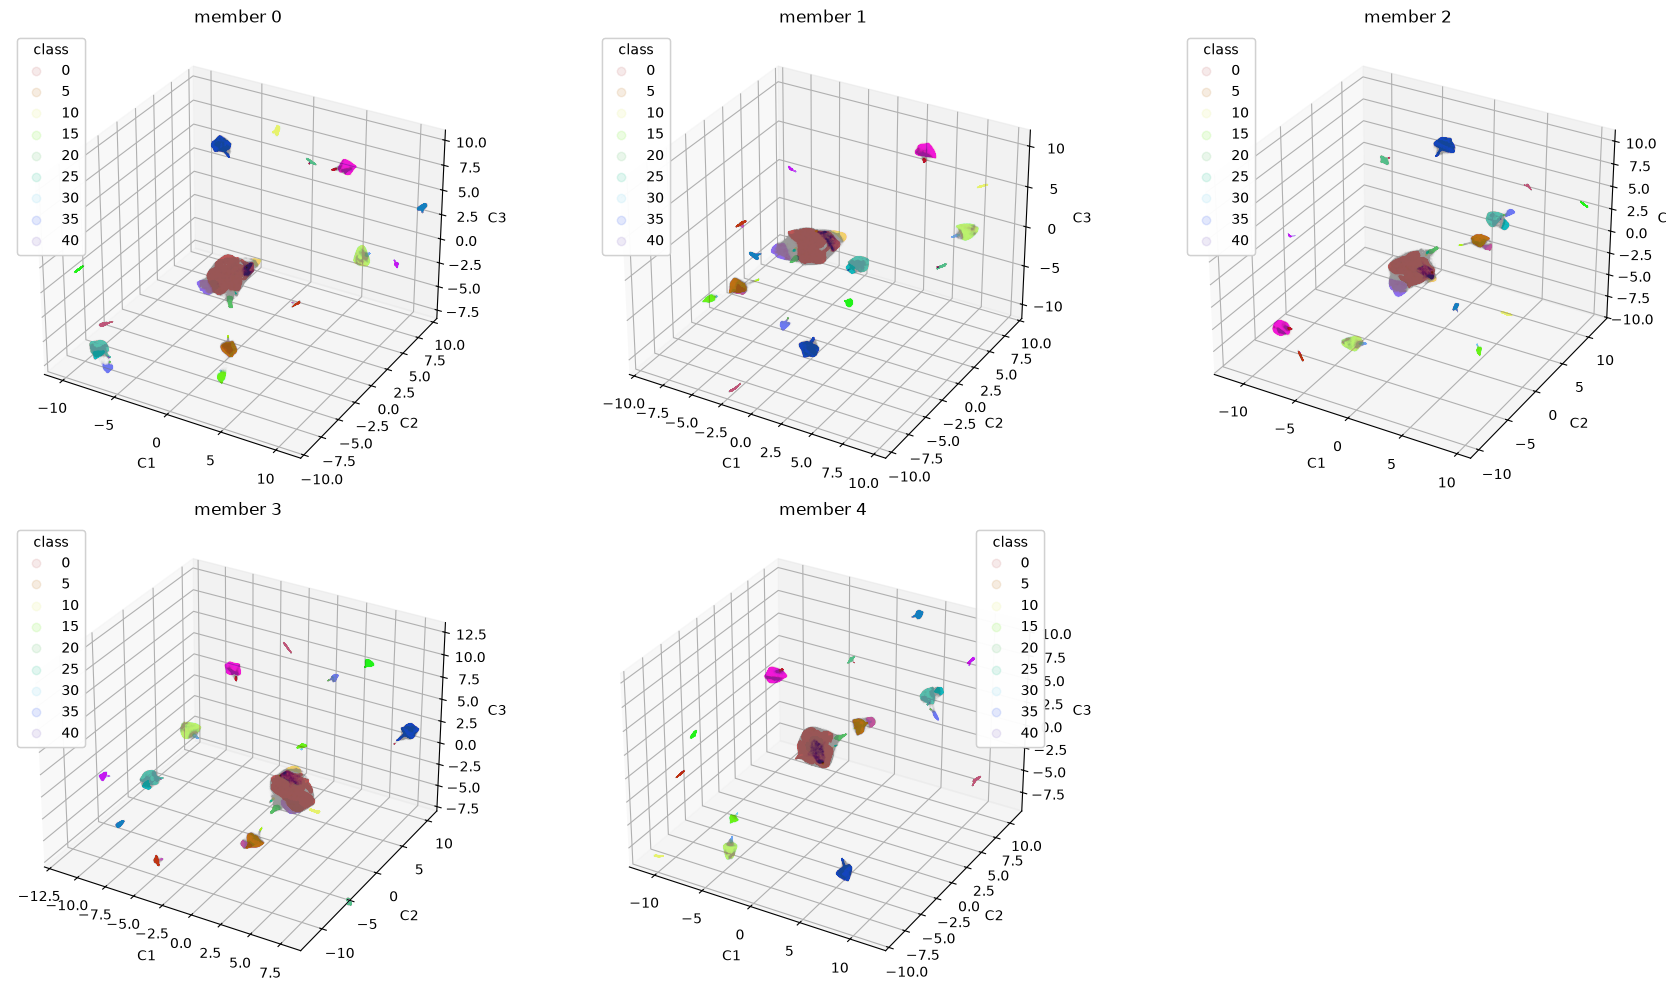

In [20]:
#labeled by consensus cluster
if ENSEMBLE_MEMEBERS > 1:
    vis.vis_dim_redux_list(embeddings, labels=clusters, dims=EMBEDDING_DIMENSIONS, titles=[f"member {i}" for i in range(len(embeddings))], alpha=0.1)
else:
    vis.vis_dim_redux(embeddings, labels=clusters, label_title="clusters", dims=EMBEDDING_DIMENSIONS, alpha=0.1)

In [ ]:
# # vis.vis_dim_redux(embeddings[1], labels=entropy, dims=2, alpha=0.5, categorical=False, cmap="viridis")
vis.vis_dim_redux_list(d["embeddings"], labels=entropy, dims=EMBEDDING_DIMENSIONS, alpha=0.2,titles=[f"member {i}" for i in range(len(d["embeddings"]))], categorical=False, cmap="viridis")

In [ ]:
vis.vis_dim_redux_list(d["embeddings"], labels=unassigned, dims=EMBEDDING_DIMENSIONS, alpha = 0.1,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))], categorical=False, cmap="viridis")

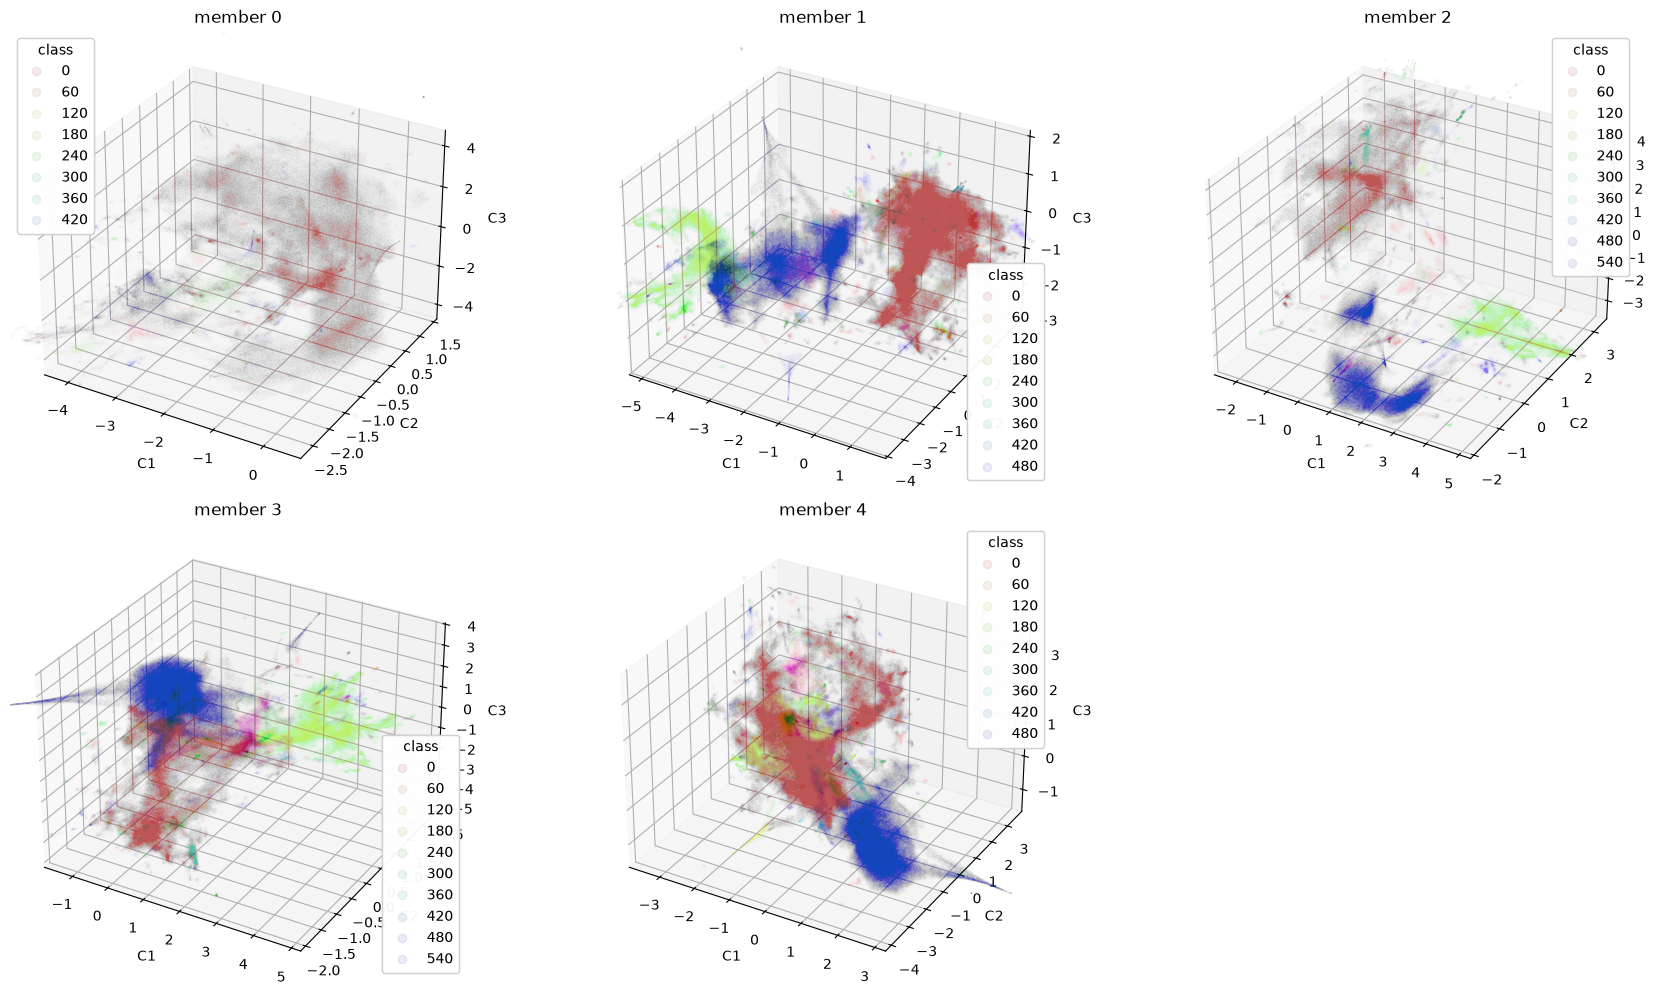

In [14]:
# colored by embedding's clustering
vis.vis_dim_redux_list(d["embeddings"], labels=d["member_clusters"], dims=EMBEDDING_DIMENSIONS, alpha=0.1,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))])

In [27]:
np.unique(clusters)

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 123, 125, 126, 127, 128, 129, 130, 131, 132, 133,
       134, 136, 137, 138, 139, 140, 141, 143, 144, 145, 146, 147, 148,
       149, 150, 151, 152, 154, 158, 159, 161, 162, 163, 169, 172, 173,
       174, 175, 176, 177, 178, 179, 182, 183, 184, 185, 186, 187, 188,
       189, 193, 194, 196, 197, 198, 199, 201, 203, 204, 207, 20

In [28]:
#  

In [ ]:
vis.make_image_from_patches(dataset, clusters, patch_size=8, number_rows=20, overlay_alpha=0.5, show_map=True)

# Cluster composition

Where the ~450 DBSCAN clusters sit in the data, what they hold, and where they
are found.  `-1` (noise) is kept throughout as a cluster of its own.

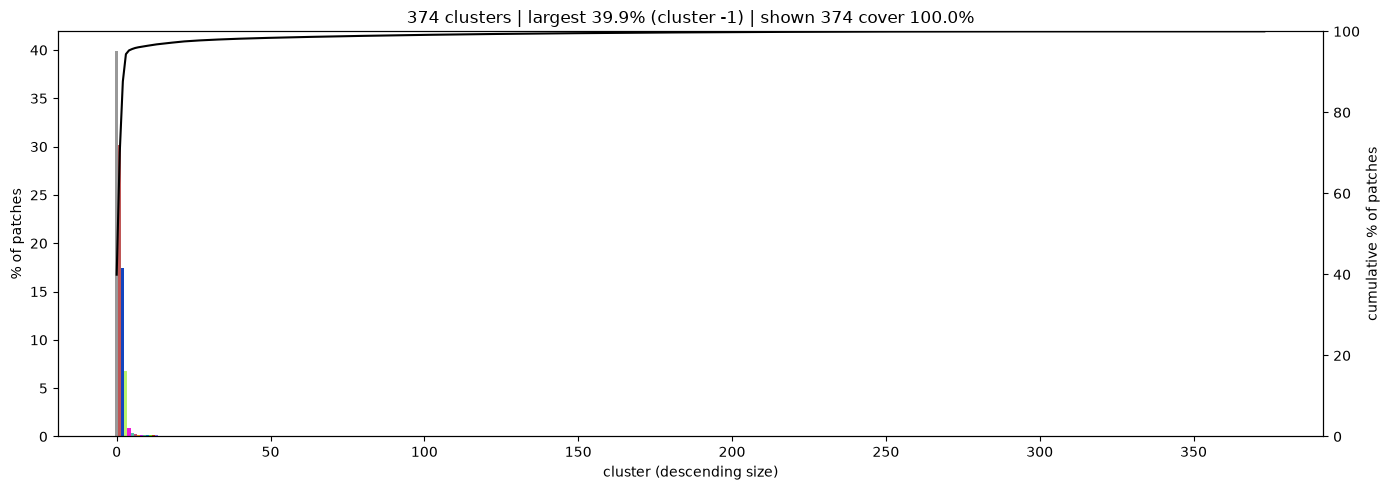

In [19]:
ids, pct = vis.plot_cluster_size_distribution(clusters)
#print(f"noise (-1) holds {pct[ids == -1][0]:.1f}% | top 20 clusters cover {pct[:20].sum():.1f}%")

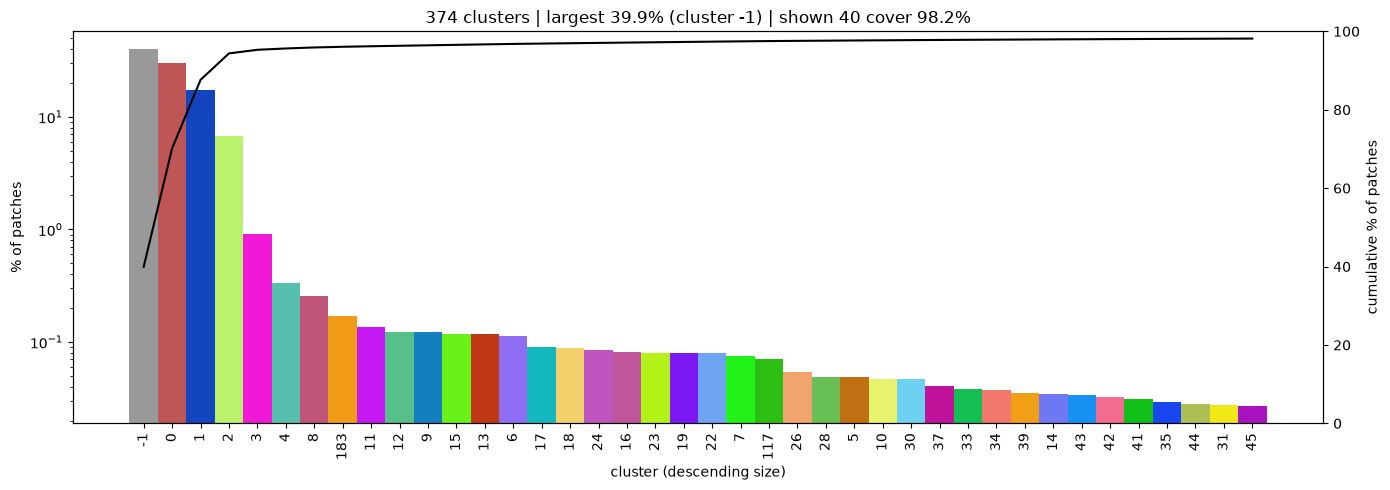

(array([ -1,   0,   1,   2,   3,   4,   8, 183,  11,  12,   9,  15,  13,
          6,  17,  18,  24,  16,  23,  19,  22,   7, 117,  26,  28,   5,
         10,  30,  37,  33,  34,  39,  14,  43,  42,  41,  35,  44,  31,
         45]),
 array([3.99393636e+01, 3.02195061e+01, 1.74604577e+01, 6.75335079e+00,
        9.18853117e-01, 3.36857033e-01, 2.58368612e-01, 1.70363274e-01,
        1.35328470e-01, 1.22935561e-01, 1.22569526e-01, 1.18124812e-01,
        1.17967939e-01, 1.12791155e-01, 9.03061310e-02, 8.84236639e-02,
        8.43972759e-02, 8.09460861e-02, 8.03708879e-02, 8.02663063e-02,
        7.99002711e-02, 7.53509755e-02, 6.98081557e-02, 5.40163482e-02,
        4.85781098e-02, 4.85258191e-02, 4.70616780e-02, 4.64864797e-02,
        4.04207523e-02, 3.78585054e-02, 3.71787256e-02, 3.54008400e-02,
        3.46164787e-02, 3.37275359e-02, 3.24725578e-02, 3.09038352e-02,
        2.93351126e-02, 2.81847160e-02, 2.76095178e-02, 2.71911917e-02]))

In [20]:
# long tail: the same distribution on a log axis, largest 40 only
vis.plot_cluster_size_distribution(clusters, top_n=40, log=True)

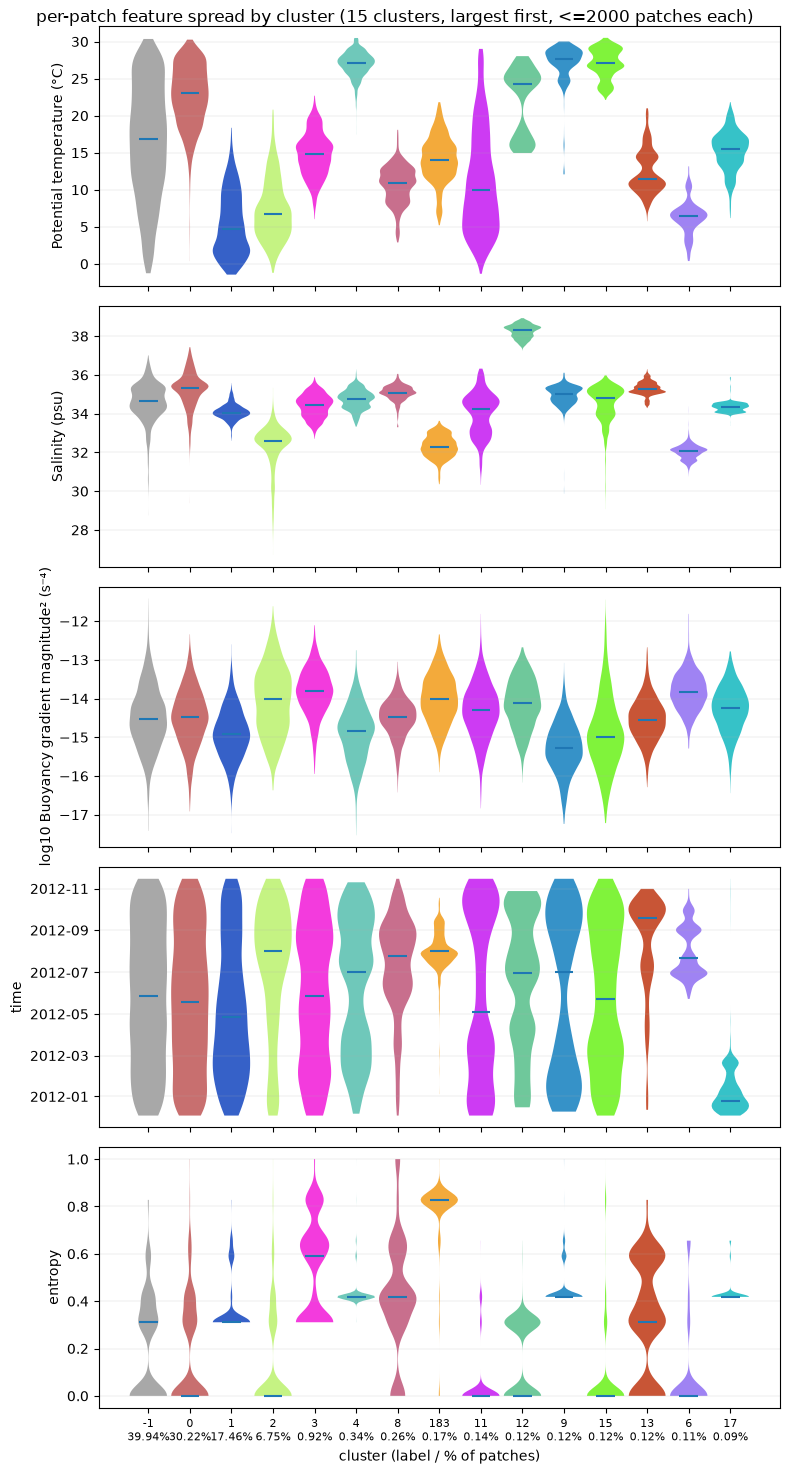

In [21]:
# feature spread within the largest clusters
vis.plot_cluster_feature_spread(dataset, clusters, features=["Theta", "Salt", "gradb2"],
                                patch_size=patch_size, top_n=15,
                                entropy=entropy, show_time=True)

In [22]:
# same, for a random sample of clusters of any size
vis.plot_cluster_feature_spread(dataset, clusters, features=["Theta", "Salt", "gradb2"],
                                patch_size=patch_size, n_clusters=20, seed=0,
                                entropy=entropy, show_time=True)

2026-08-18 01:20:57,344 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
  File "/home/jovyan/conda_envs/main_cuml/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jovyan/conda_envs/main_cuml/lib/python3.12/asyncio/base_events.py", line 691, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/nanny.py", line 985, in run
    await worker.finished()
  File "/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/core.py", line 494, in finished
    await self._event_finished.wait()
  File "/home/jovyan/conda_envs/main_cuml/lib/python3.12/asyncio/locks.py", line 212, in wait
    await fut
asyncio.exceptions.CancelledError

Du

KeyboardInterrupt: 

In [ ]:
vis.plot_top_cluster_maps(dataset, clusters, patch_size=patch_size, top_n=12, n_cols=4)

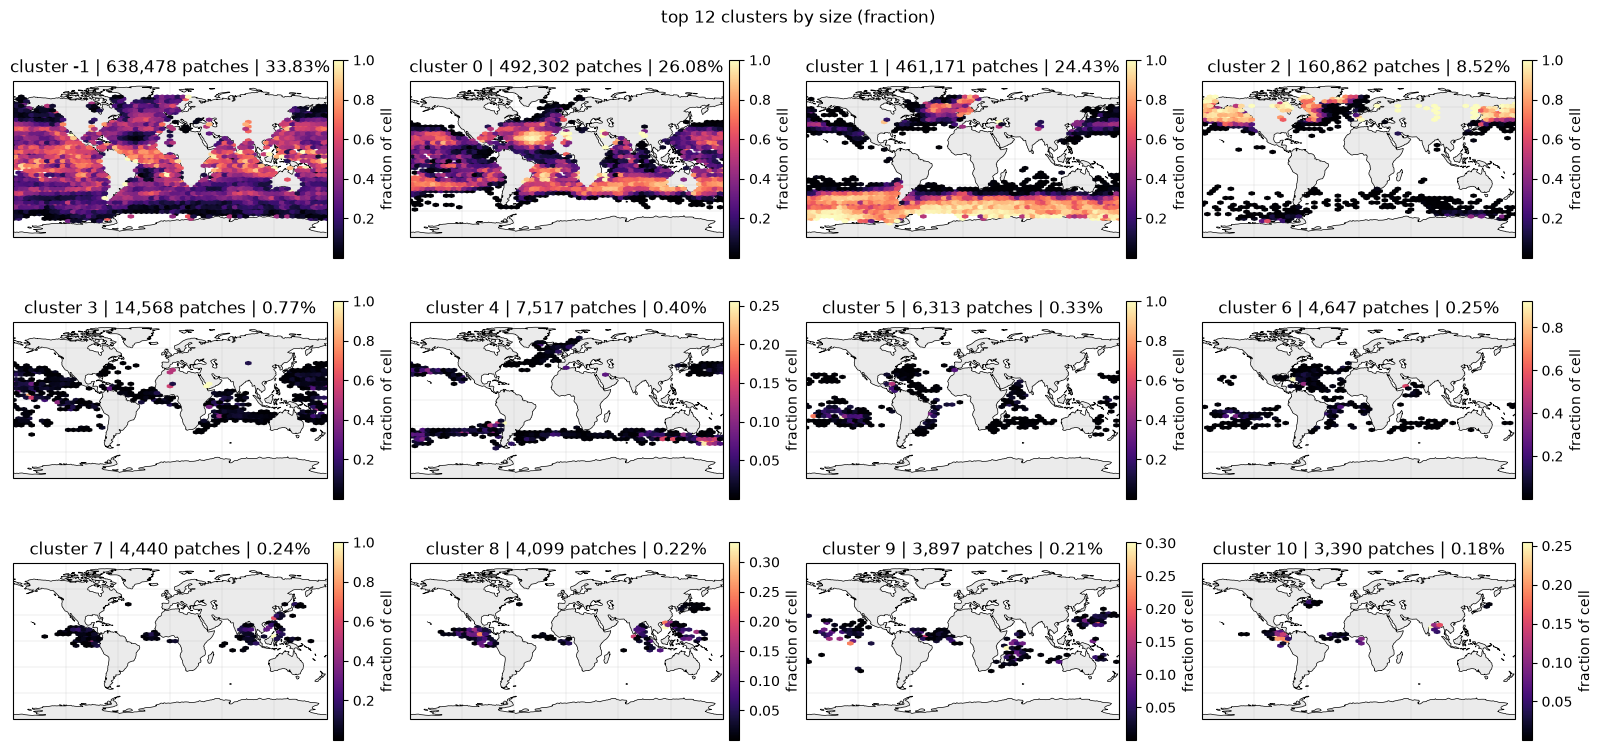

In [45]:
# prevalence instead of raw counts, which divides out the uneven sampling density
vis.plot_top_cluster_maps(dataset, clusters, patch_size=patch_size, top_n=12, n_cols=4,
                          normalize="fraction")

cluster 0: 15,500 patches across 1,598 cutouts | richest holds 54 of 64


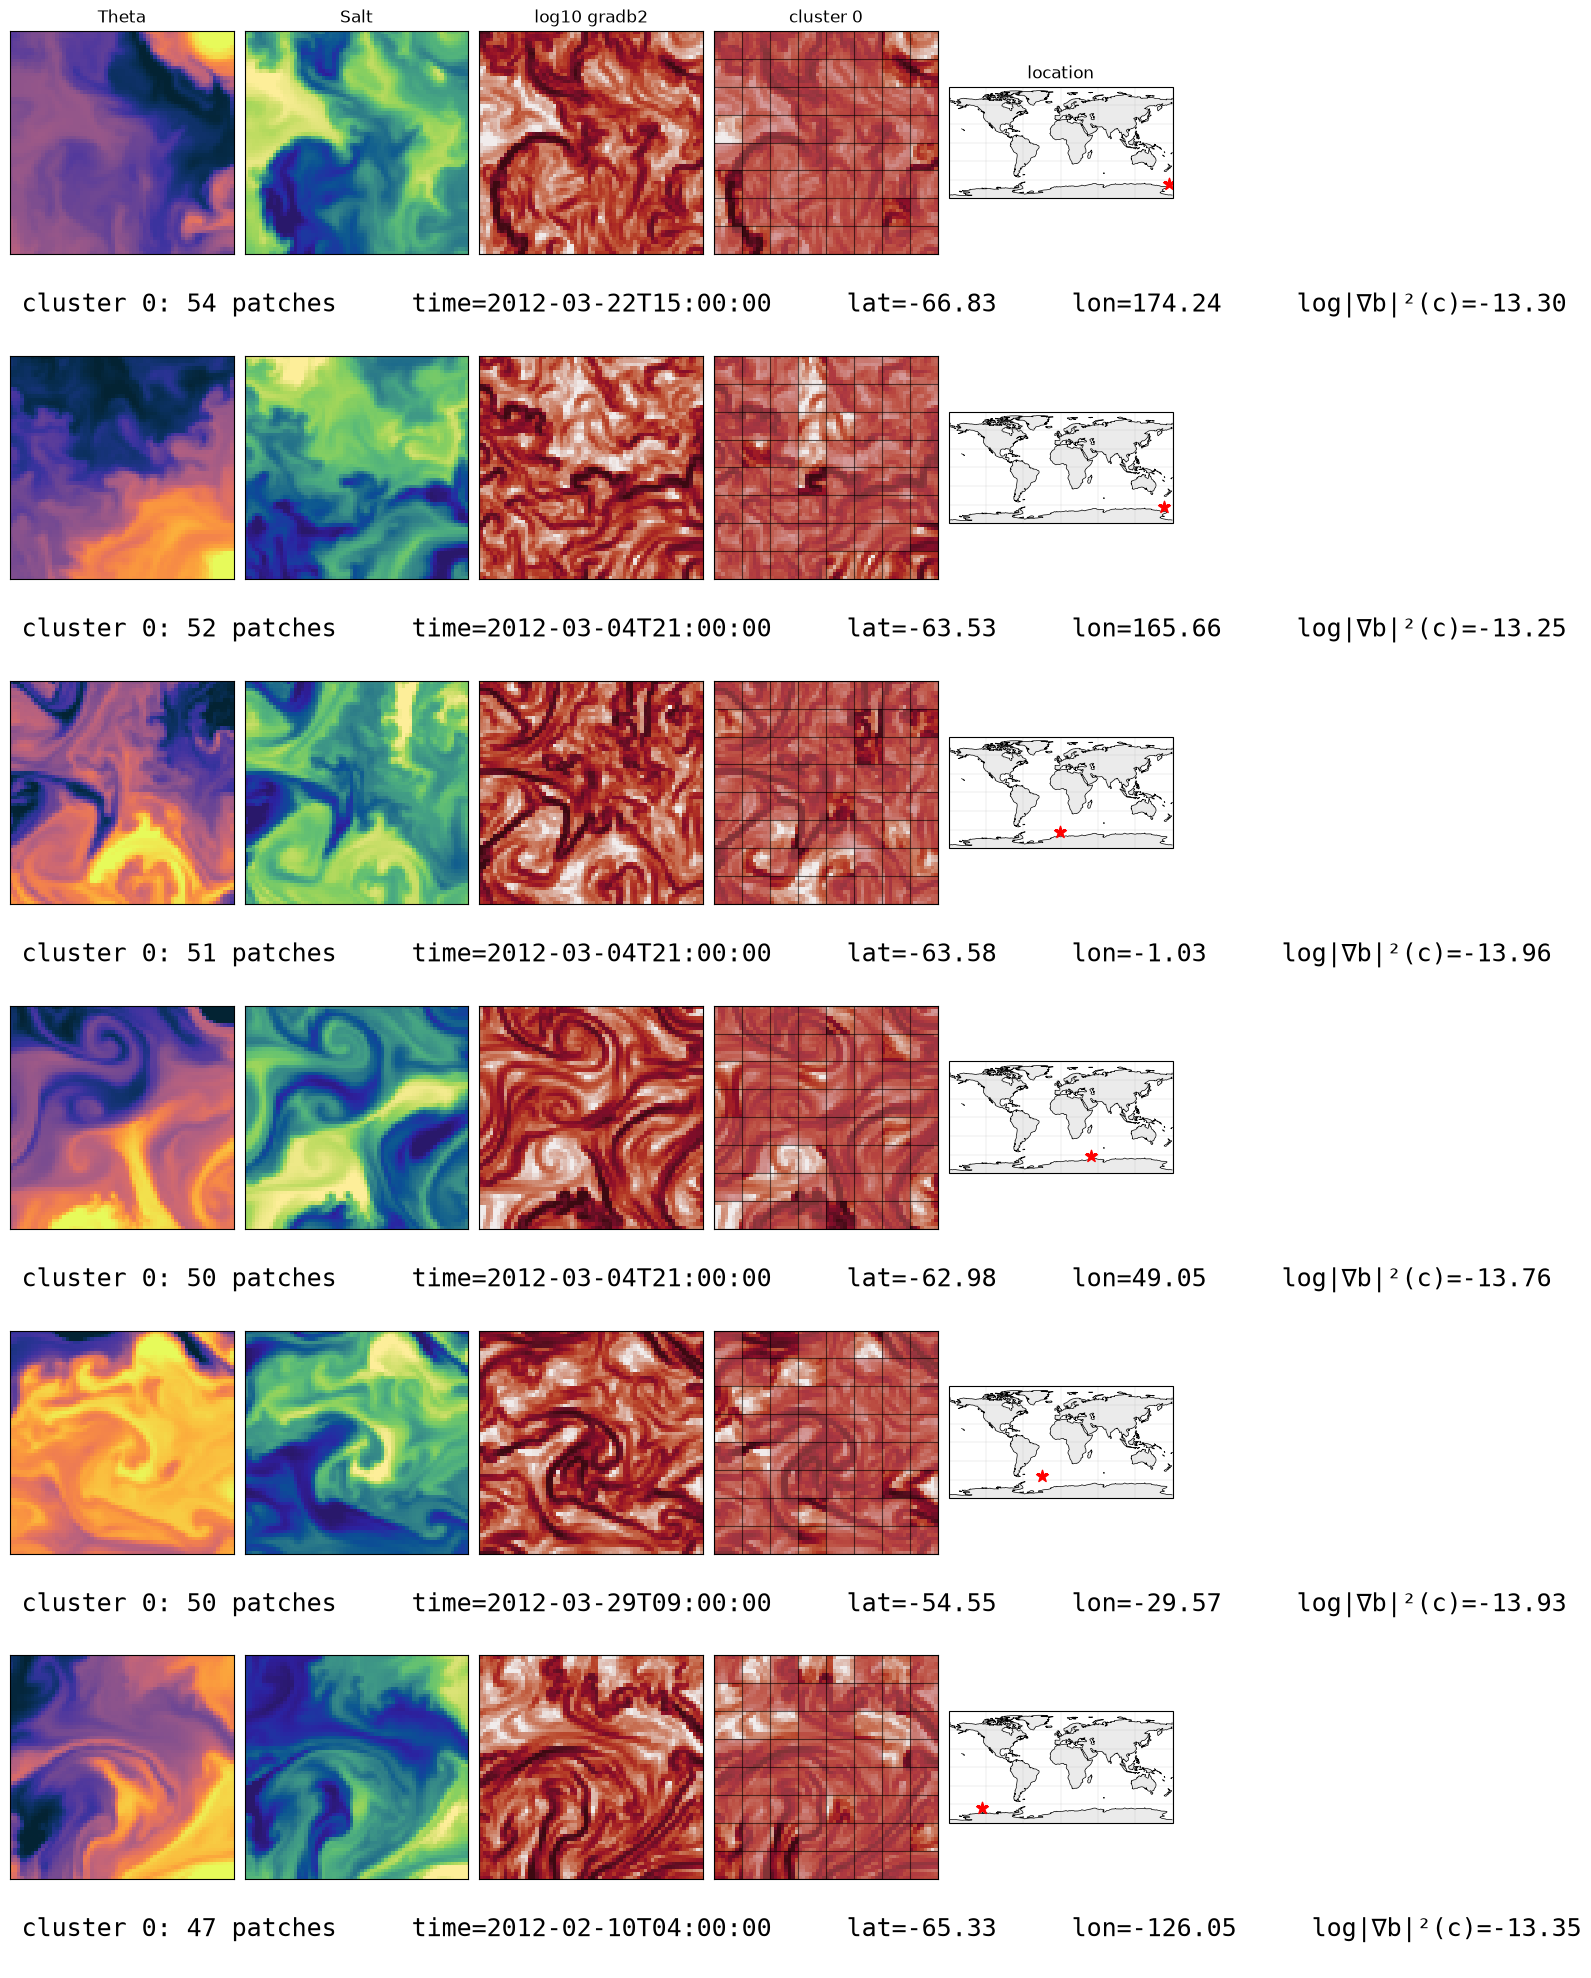

In [19]:
# cutouts holding a given cluster, richest first; `cluster` is the actual label
# shown by the maps above, not a size rank
top_cluster = int(ids[ids >= 0][0])
vis.plot_cluster_cutouts(dataset, clusters, top_cluster,
                         features=["Theta", "Salt", "gradb2"],
                         patch_size=patch_size, number_rows=6)

cluster 7: 9,442 patches across 431 cutouts | richest holds 64 of 64


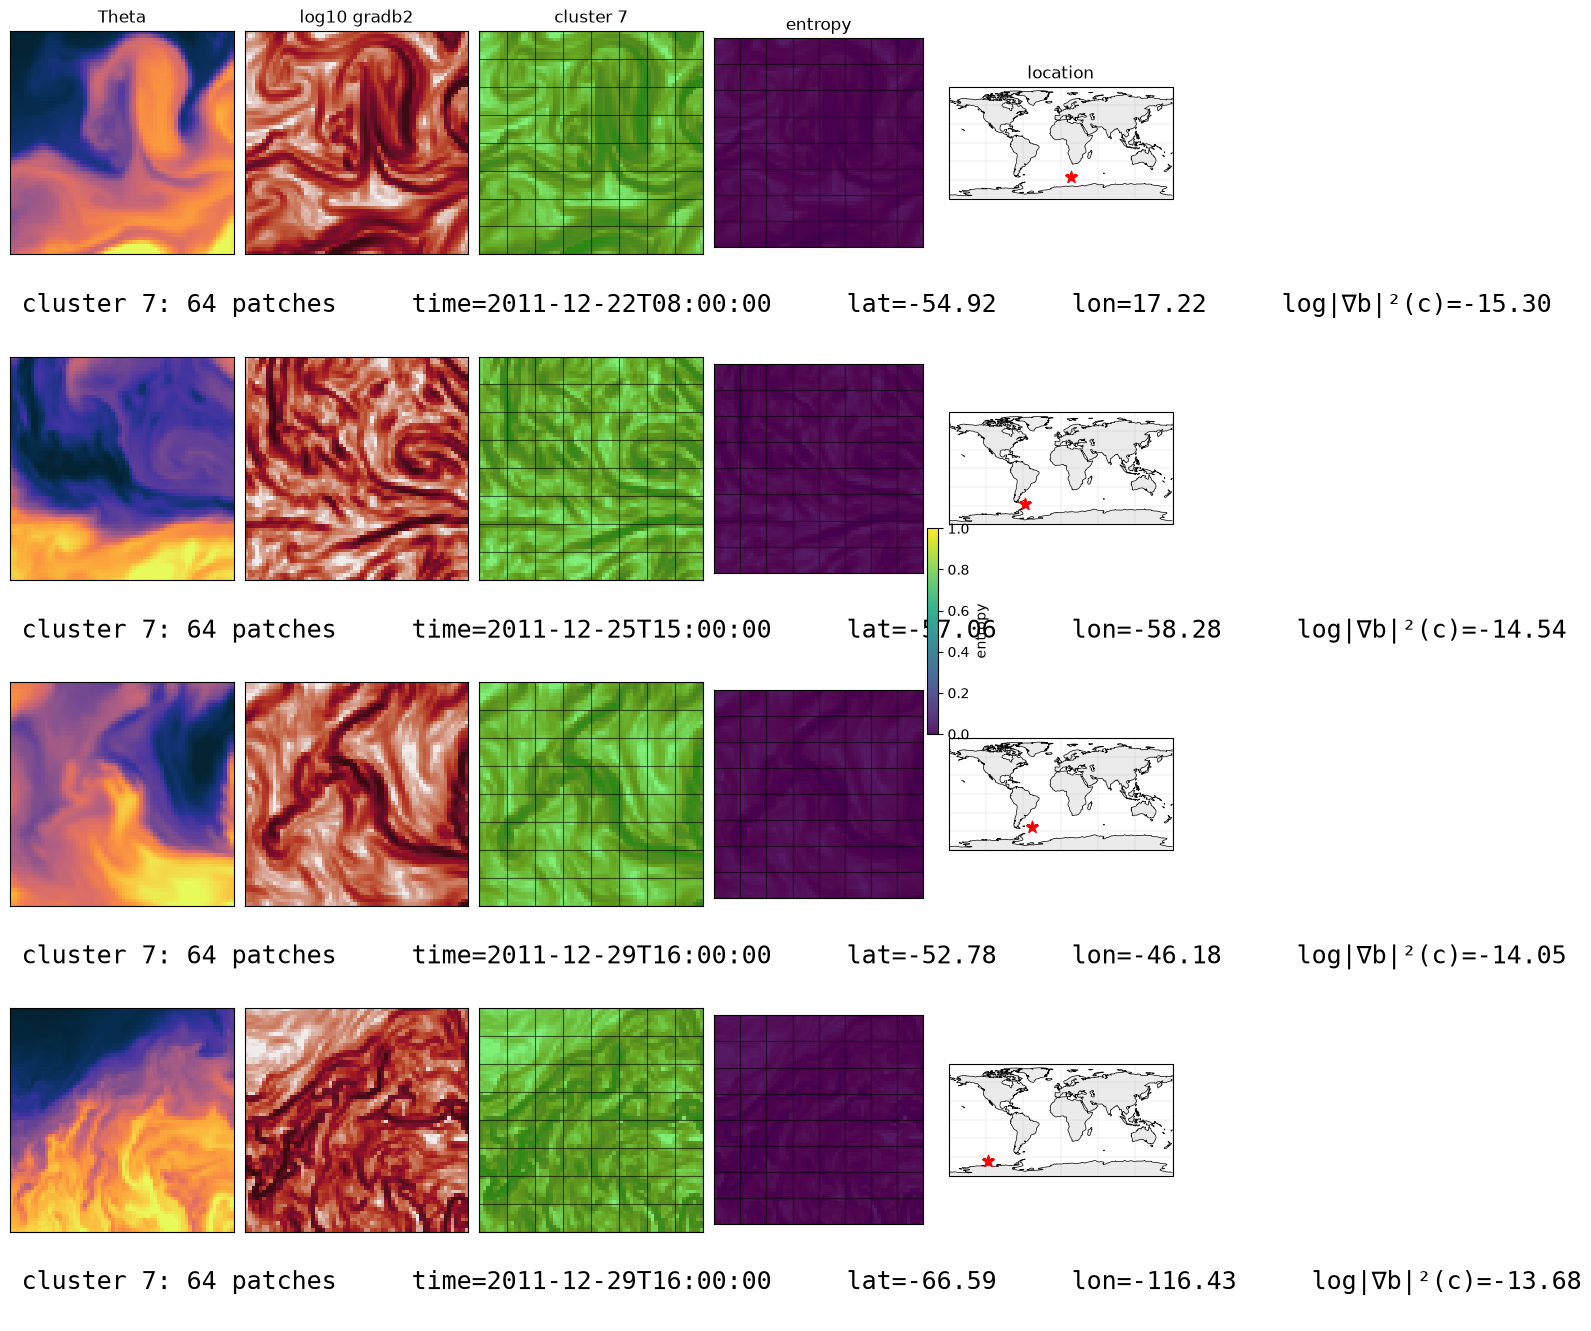

In [20]:
# any label works, and entropy adds its own column
vis.plot_cluster_cutouts(dataset, clusters, 7,
                         features=["Theta", "gradb2"], patch_size=patch_size,
                         number_rows=4, start=6, entropy=entropy)